### 练习1：体验网格分辨率的影响

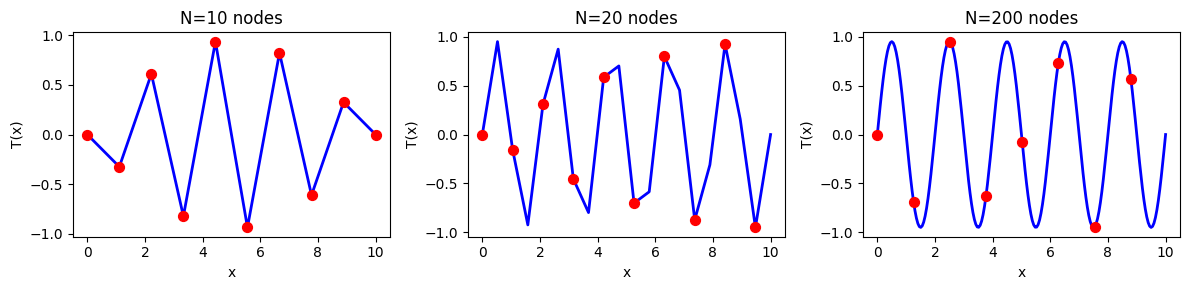

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# 一维热方程的解析解
def exact_solution(x, t, alpha=0.1):
    return np.exp(-alpha * np.pi**2 * t) * np.sin(np.pi * x)

# 对比不同网格分辨率
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for i, N in enumerate([10, 20, 200]):
    x = np.linspace(0, 10, N)
    u = exact_solution(x, t=0.05)
    axes[i].plot(x, u, 'b-', linewidth=2)
    axes[i].scatter(x[::max(1, N//8)], u[::max(1, N//8)], 
                   color='red', s=50, zorder=5)
    axes[i].set_title(f'N={N} nodes')
    axes[i].set_xlabel('x')
    axes[i].set_ylabel('T(x)')
fig.tight_layout()
plt.show()

### 练习2：比较ODE和PDE

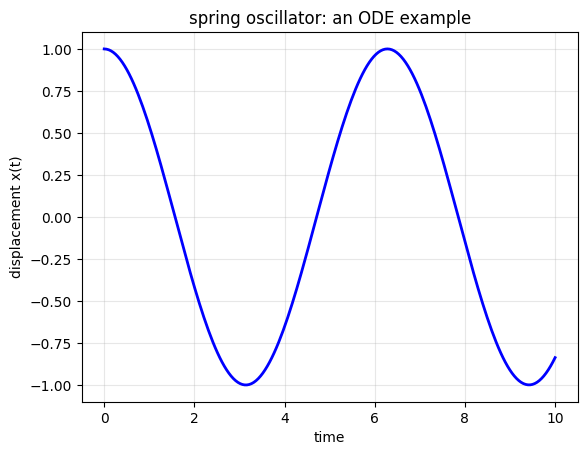

In [ ]:
from scipy.integrate import solve_ivp

# ODE：弹簧振子 m*d²x/dt² + k*x = 0
def spring_ode(t, y, k=1.0, m=1.0):
    x, v = y  # y = [位置, 速度]
    return [v, -k/m * x]

sol = solve_ivp(spring_ode, [0, 10], [1.0, 0.0],
                t_eval=np.linspace(0, 10, 200))

import matplotlib.pyplot as plt
plt.plot(sol.t, sol.y[0], 'b-', linewidth=2)
plt.xlabel('time')
plt.ylabel('displacement x(t)')
plt.title('spring oscillator: an ODE example')
plt.grid(True, alpha=0.3)
plt.show()